In [304]:
import random
import ast
import inspect
import instructor
import json

from pydantic import BaseModel, Field
from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from operator import add

from IPython.display import Image, display

from openai import OpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, convert_to_openai_messages, convert_to_messages

from utils.utils import get_tool_descriptions, format_ai_message

### Single Node Graph

In [216]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str

In [217]:
def append_vibe_to_query(state: State) -> dict:

    return {
        "answer": f"{state.message} {state.vibe}"
    }

In [218]:
workflow = StateGraph(State)
workflow.add_node("append_vibe_to_query", append_vibe_to_query)
workflow.add_edge(START, "append_vibe_to_query")
workflow.add_edge("append_vibe_to_query", END)

graph = workflow.compile()

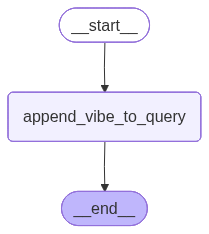

In [219]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [220]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I am feeling like a log today"
}

In [221]:
result = graph.invoke(initial_state)

In [ ]:
 Humane Hqsasasd

{'message': 'Give me some vibes!',
 'answer': 'Give me some vibes! I am feeling like a log today',
 'vibe': 'I am feeling like a log today'}

In [223]:
initial_state = {
    "message": "Give me some vibes!",
    "vibe": "I am feeling like a log today",
    "answer": "abc"
}

In [224]:
result = graph.invoke(initial_state)

In [225]:
result

{'message': 'Give me some vibes!',
 'answer': 'Give me some vibes! I am feeling like a log today',
 'vibe': 'I am feeling like a log today'}

### Conditional Graph

In [226]:
class State(BaseModel):
    message: str
    answer: str = ""

In [227]:
def get_the_answer(state: State) -> dict:

    return {
        "answer": state.message
    }

In [228]:
def append_vibe_1(state: State) -> dict:
    vibe = "Hell Yeah!"

    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_2(state: State) -> dict:
    vibe = "Woohooo!"

    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_3(state: State) -> dict:
    vibe = "Rock'n'Roll"

    return {
        "answer": f"{state.message} {vibe}"
    }

In [229]:
def router_function(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:

    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]
    vibe_path = random.choice(vibes)

    return vibe_path

In [230]:
workflow = StateGraph(State)

workflow.add_node("get_the_answer", get_the_answer)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "get_the_answer",
    router_function
)
workflow.add_edge(START, "get_the_answer")

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()

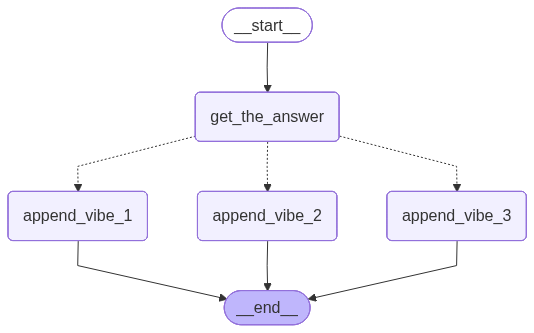

In [231]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [232]:
initial_state = {
    "message": "I am here to have a great time."
}

In [233]:
result = graph.invoke(initial_state)

In [234]:
result

{'message': 'I am here to have a great time.',
 'answer': 'I am here to have a great time. Hell Yeah!'}

In [235]:
result = graph.invoke(initial_state)
result

{'message': 'I am here to have a great time.',
 'answer': 'I am here to have a great time. Woohooo!'}

In [236]:
result = graph.invoke(initial_state)
result

{'message': 'I am here to have a great time.',
 'answer': 'I am here to have a great time. Woohooo!'}

In [237]:
result = graph.invoke(initial_state)
result

{'message': 'I am here to have a great time.',
 'answer': 'I am here to have a great time. Hell Yeah!'}

### Agent Graph

In [238]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: the query to append the vibe to.
        vibe: The vibe to appened to the query.
    
    Returns:
        A string with the query and a vibe appended.
    """

    return f"{query} {vibe}"

In [239]:
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'the query to append the vibe to.'},
    'vibe': {'type': 'string',
     'description': 'The vibe to appened to the query.'}},
   'required': ['query', 'vibe']},
  'returns': {'type': 'string',
   'description': 'A string with the query and a vibe appended.'}}]

In [240]:
class ToolCall(BaseModel):
    name: str
    arguments: dict

class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = []

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [241]:
def agent_node(state: State) -> dict:
    
    prompt_template = """You are an assistant that is generting vibes for a user.

## Tools

<Available tools>
{{ available_tools | tojson }}
</Available tools>

Use only the tools names listed above, exactly as written. Place all parameters inside the "arguments" object.

## Tool Call Example

- Append vibes to the user's query:
{
    "name": "append_vibes",
    "arguments": {"query": "Give me soome vibes!", "vibe": "Hell Yeah!"}
}

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
"""
    prompt = Template(prompt_template).render(available_tools=state.available_tools)

    client = instructor.from_provider(
        model="openai/gpt-4.1-mini",
        #mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": state.message}
        ],
        response_model=AgentResponse
    )

    ai_message = format_ai_message(response)

    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls
    }

## Short explainer on message types and formatting

In [242]:
conversation = [
    {'role': 'user', 'content': 'Give me some vibes!'},
    {'role': 'assistant', 'content': 'I am here to add some vibes!'},
    {'role': 'user', 'content': 'I am feeling like a superhero today!'}
]

In [243]:
convert_to_messages(conversation)

[HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am here to add some vibes!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am feeling like a superhero today!', additional_kwargs={}, response_metadata={})]

In [244]:
convert_to_openai_messages(convert_to_messages(conversation))

[{'role': 'user', 'content': 'Give me some vibes!'},
 {'role': 'assistant', 'content': 'I am here to add some vibes!'},
 {'role': 'user', 'content': 'I am feeling like a superhero today!'}]

In [245]:
dummy_response = AgentResponse(answer="I am here to add some vibes!", tool_calls=[ToolCall(name="append_vibes", arguments={'query': 'Give me some vibes!','vibe': 'I am feeling like a superhero today!'})])

In [246]:
format_ai_message(dummy_response)

AIMessage(content='I am here to add some vibes!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'I am feeling like a superhero today!'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])

### End of short explainer on message format

In [247]:
def tool_router(state: State) -> dict:
    
    if len(state.tool_calls) > 0:
        return "tools"
    
    return "end"

In [248]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

In [249]:
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", END)
graph = workflow.compile()

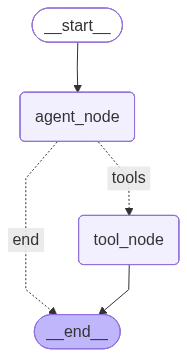

In [250]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [251]:
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions,
}

In [252]:
result = graph.invoke(initial_state)
result

{'messages': [AIMessage(content='Generating some vibes for you!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'Chill and cool vibes'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Give me some vibes! Chill and cool vibes', name='append_vibes', tool_call_id='call_0')],
 'message': 'Give me some vibes!',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'the query to append the vibe to.'},
     'vibe': {'type': 'string',
      'description': 'The vibe to appened to the query.'}},
    'required': ['query', 'vibe']},
   'returns': {'type': 'string',
    'description': 'A string with the query and a vibe appended.'}}],
 'tool_calls': [ToolCall(name='append_vibes', a

### Agent Graph with Loopback from Tools (ReAct Agent)

In [253]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: the query to append the vibe to.
        vibe: The vibe to appened to the query.
    
    Returns:
        A string with the query and a vibe appended.
    """

    return f"{query} {vibe}"

In [254]:
class ToolCall(BaseModel):
    name: str
    arguments: dict

class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = []

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [315]:
def agent_node(state: State) -> dict:
    
    prompt_template = """You are an assistant that is generting vibes for a user.

## Tools

<Available tools>
{{ available_tools | tojson }}
</Available tools>

Use only the tools names listed above, exactly as written. Place all parameters inside the "arguments" object.

## Tool Call Example

- Append vibes to the user's query:
{
    "name": "append_vibes",
    "arguments": {"query": "Give me soome vibes!", "vibe": "Hell Yeah!"}
}

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
"""
    prompt = Template(prompt_template).render(available_tools=state.available_tools)
    
    if state.iteration == 0:
        conversation = []
        conversation.append({'role': 'user', 'content': state.message})
    else:
        conversation = []
        for message in state.messages:
            conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        model="openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        response_model=AgentResponse
    )
    ai_message = format_ai_message(response)
    if state.iteration == 0:
        messages = [HumanMessage(state.message), ai_message]
    else:
        messages = [ai_message]
    return {
        "messages": messages,
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer
    }

In [316]:
def tool_router(state: State) -> str:
    
    if state.iteration > 2:
        return "end"
    
    elif len(state.tool_calls) > 0:
        return "tools"
    
    return "end"

In [317]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

In [318]:
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
graph = workflow.compile()

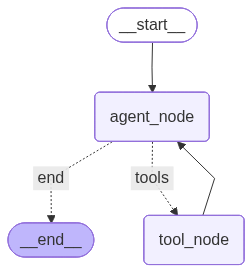

In [319]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [320]:
initial_state = {
    "message": "Give me some vibes!",
    "available_tools": tool_descriptions,
}

In [321]:
result = graph.invoke(initial_state)
result

{'messages': [HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Adding some vibes to your request!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'Awesome vibes'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='Give me some vibes! Awesome vibes', name='append_vibes', tool_call_id='call_0'),
  AIMessage(content='Give me some vibes! Awesome vibes', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'message': 'Give me some vibes!',
 'iteration': 2,
 'answer': 'Give me some vibes! Awesome vibes',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'the query to append the vibe